<a href="https://colab.research.google.com/github/scalabrinig/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_entrega_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 4**

---

# **Título do Projeto**: Previsão de Vendas com Séries Temporais — Dataset Amazon

---

In [1]:
Aluno1 = 'Vitor Assunção Rocha, 10440984'

# **Resumo**

O crescimento acelerado do comércio eletrônico gera volumes massivos de dados históricos de transações que, quando bem explorados, permitem antecipar o comportamento futuro das vendas. Este projeto aborda o problema de **previsão de faturamento semanal** em uma plataforma de e-commerce, utilizando o Amazon Sales Dataset (~100 mil registros de pedidos de 2022 a 2023). A relevância da solução reside no suporte à tomada de decisão estratégica: otimização de estoques, planejamento logístico e alocação de campanhas promocionais. A metodologia empregada segue um pipeline de Ciência de Dados que compreende análise exploratória, pré-processamento e decomposição de séries temporais, implementação e comparação de dois modelos preditivos — **ARIMA/SARIMA** (seleção automática de parâmetros via critério AIC) e **Prophet** (Facebook/Meta) — e avaliação por meio das métricas MAE, RMSE e MAPE. Os resultados indicam que o Prophet apresentou desempenho superior ao ARIMA na série semanal de faturamento, capturando com maior fidelidade a sazonalidade e a tendência de crescimento presentes nos dados.

# **Introdução**

## Contexto e Motivação

O comércio eletrônico vive um crescimento acelerado e contínuo. Plataformas como a Amazon processam milhões de pedidos por dia, gerando grandes volumes de dados históricos de transações. Esses dados carregam padrões temporais valiosos — sazonalidades, tendências de demanda, picos em datas comerciais — que, quando bem explorados, permitem antecipar o comportamento futuro das vendas. A capacidade de prever vendas com precisão é estratégica para o varejo online: permite otimizar estoques, alocar recursos logísticos, planejar campanhas promocionais e reduzir perdas por excesso ou falta de produto. Neste contexto, modelos de séries temporais surgem como ferramentas poderosas, pois capturam a dependência temporal intrínseca nos dados de vendas.

## Objetivo Geral

Desenvolver um pipeline de previsão de vendas para o dataset Amazon, aplicando técnicas de séries temporais a fim de estimar o volume de faturamento total em horizontes futuros de 4 a 8 semanas, comparando o desempenho de modelos estatísticos clássicos (ARIMA) e modernos (Prophet).

## Objetivos Específicos

- Realizar análise exploratória dos dados históricos de pedidos, identificando tendências, sazonalidades e anomalias;
- Agregar os dados de pedidos em granularidades temporais adequadas (diária e semanal);
- Pré-processar as séries temporais (tratamento de valores ausentes, normalização e decomposição);
- Implementar e comparar dois modelos preditivos: ARIMA (com seleção automática de ordem via AIC) e Prophet;
- Avaliar o desempenho dos modelos por meio de métricas como MAE, RMSE e MAPE;
- Gerar previsões para as próximas semanas e interpretar os resultados no contexto do negócio.

## Base de Dados

O dataset utilizado é o **Amazon Sales Dataset**, composto por aproximadamente **100.000 registros** de pedidos, com as seguintes variáveis principais: `OrderID`, `OrderDate`, `CustomerID`, `ProductID`, `ProductName`, `Category`, `Brand`, `Quantity`, `UnitPrice`, `Discount`, `Tax`, `ShippingCost`, `TotalAmount`, `PaymentMethod`, `OrderStatus`, `City`, `State` e `Country`. O período coberto pelos dados abrange os anos de 2022 e 2023, com pedidos distribuídos em diversas categorias de produtos e regiões geográficas.

## Justificativa

A previsão de vendas é um dos problemas mais relevantes e recorrentes no varejo. A utilização de séries temporais sobre um dataset real e de grande volume permite não apenas explorar técnicas consolidadas de forecasting, mas também lidar com desafios práticos como dados faltantes, múltiplas sazonalidades e ruído inerente ao comportamento de consumo. Este projeto contribui para o desenvolvimento de competências em análise temporal, modelagem preditiva e interpretação orientada ao negócio.

# **Referencial Teórico**

## Séries Temporais

Uma série temporal é uma sequência de observações coletadas ao longo do tempo em intervalos regulares. Sua análise baseia-se na identificação de componentes estruturais: **tendência** (movimento de longo prazo), **sazonalidade** (padrões cíclicos de curto prazo) e **resíduo** (variações aleatórias) (BOX; JENKINS; REINSEL, 2015). A decomposição da série nessas componentes é um passo essencial antes da modelagem preditiva.

## Modelos ARIMA e SARIMA

O modelo **ARIMA** (*AutoRegressive Integrated Moving Average*) combina processos autorregressivos (AR), diferenciação para estacionarização (I) e médias móveis (MA), sendo parametrizado por (p, d, q). Sua extensão sazonal, o **SARIMA**, incorpora termos sazonais (P, D, Q, s), tornando-o adequado para séries com padrões periódicos. Esses modelos são amplamente utilizados em previsão de demanda no varejo (HYNDMAN; ATHANASOPOULOS, 2021).

## Prophet

Desenvolvido pelo Facebook (atual Meta), o **Prophet** é um modelo aditivo de séries temporais especialmente robusto a dados faltantes, outliers e mudanças de tendência. Modela explicitamente feriados e sazonalidades múltiplas (TAYLOR; LETHAM, 2018), sendo amplamente adotado em aplicações de negócios por sua facilidade de uso e interpretabilidade. O Prophet decompõe a série em componentes de tendência, sazonalidade anual, semanal e efeito de feriados, o que o torna particularmente adequado para dados de varejo.

## Trabalhos Correlacionados

Estudos anteriores aplicaram modelos de séries temporais à previsão de vendas no e-commerce com resultados promissores. Fildes et al. (2019) demonstraram que modelos SARIMA superam métodos ingênuos (naive) em horizontes curtos de previsão para produtos de alta rotatividade. Já Bandara et al. (2020) compararam ARIMA, Prophet e redes neurais recorrentes (LSTM), concluindo que modelos estatísticos clássicos apresentam desempenho competitivo quando o volume de dados históricos é limitado, enquanto modelos de deep learning se destacam com séries longas e múltiplas variáveis.

## Métricas de Avaliação

As principais métricas utilizadas para avaliar modelos de forecasting são: **MAE** (*Mean Absolute Error*), que mede o erro absoluto médio; **RMSE** (*Root Mean Squared Error*), mais sensível a grandes erros; e **MAPE** (*Mean Absolute Percentage Error*), que expressa o erro em termos percentuais, facilitando a comparação entre séries de diferentes escalas (HYNDMAN; ATHANASOPOULOS, 2021).

# **Diagrama de Solução**

O pipeline proposto para a resolução do problema de previsão de vendas é composto pelas seguintes etapas:

---

## Etapa 1 — Coleta e Carregamento dos Dados

Carregamento do dataset `Amazon.csv` (≈100.000 registros) utilizando a biblioteca `pandas`. Verificação inicial das dimensões, tipos de dados e valores ausentes.

---

## Etapa 2 — Análise Exploratória dos Dados (EDA)

- Distribuição temporal dos pedidos (por dia, semana e mês);
- Análise por categoria de produto, método de pagamento e status do pedido;
- Identificação visual de tendências, sazonalidades e outliers;
- Decomposição da série temporal (tendência + sazonalidade + resíduo).

---

## Etapa 3 — Pré-processamento

- Conversão da coluna `OrderDate` para o tipo `datetime`;
- Agregação dos dados em séries temporais de `TotalAmount` nas granularidades diária e semanal;
- Tratamento de datas sem registros (preenchimento com zero);
- Teste de estacionariedade (ADF — *Augmented Dickey-Fuller*) e diferenciação quando necessário;
- Divisão dos dados em conjuntos de treino e teste (últimas 8 semanas para teste).

---

## Etapa 4 — Modelagem

Serão desenvolvidos e comparados os seguintes modelos:

| Modelo | Biblioteca | Observação |
|---|---|---|
| ARIMA | `statsmodels` | Seleção automática de parâmetros via AIC |
| Prophet | `prophet` | Modelagem de sazonalidades e feriados |

Para cada modelo, serão ajustados hiperparâmetros e geradas previsões no horizonte de 8 semanas.

---

## Etapa 5 — Avaliação dos Modelos

- Cálculo das métricas MAE, RMSE e MAPE sobre o conjunto de teste;
- Análise dos resíduos (autocorrelação, distribuição);
- Comparação visual entre valores reais e previstos;
- Seleção do modelo com melhor desempenho.

---

## Etapa 6 — Geração de Previsões e Interpretação

- Geração de previsões futuras com o modelo selecionado;
- Visualização das previsões com intervalos de confiança;
- Interpretação dos resultados no contexto de negócio (picos de demanda, tendências de crescimento);
- Documentação e conclusões.

---

### Diagrama do Pipeline

```
Amazon.csv
    │
    ▼
[1] Carregamento dos Dados
    │
    ▼
[2] Análise Exploratória (EDA)
    │
    ▼
[3] Pré-processamento e Engenharia de Features
    │
    ├──────────────────────────┐
    ▼                          ▼
[4a] Modelo ARIMA           [4b] Modelo Prophet
    │                          │
    └──────────┬───────────────┘
               ▼
[5] Avaliação Comparativa (MAE / RMSE / MAPE)
               │
               ▼
[6] Previsões Futuras + Interpretação
```

# **EDA e Pré-processamento dos dados**

A base de dados Amazon Sales Dataset foi carregada e submetida a um processo rigoroso de exploração e preparação. As principais tarefas realizadas foram: verificação da integridade dos dados (valores nulos e duplicados), identificação de anomalias (inconsistências geográficas e categóricas típicas de datasets sintéticos), engenharia de variáveis temporais, agregação das séries de faturamento em granularidade diária e semanal, decomposição clássica da série, teste de estacionariedade ADF e divisão treino/teste. O dataset apresenta boa qualidade geral, sem valores nulos, embora exiba algumas inconsistências de categorização e geolocalização que, por serem de natureza sintética, não impactam a modelagem temporal.

In [2]:
# ── 1. Importação das Bibliotecas e Leitura de Dados ──────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Carregamento do dataset
df = pd.read_csv('Amazon.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 20)


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [3]:
# ── 2. Dimensão e Volumes ──────────────────────────────────────────────────
print(f'Registros (Linhas): {df.shape[0]}')
print(f'Atributos (Colunas): {df.shape[1]}')
df.info()

Registros (Linhas): 100000
Atributos (Colunas): 20
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  str    
 1   OrderDate      100000 non-null  str    
 2   CustomerID     100000 non-null  str    
 3   CustomerName   100000 non-null  str    
 4   ProductID      100000 non-null  str    
 5   ProductName    100000 non-null  str    
 6   Category       100000 non-null  str    
 7   Brand          100000 non-null  str    
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  str    
 15  OrderStatus    100000 non-null  str    
 16  City           100000 non-null  str

In [4]:
# ── 3. Avaliação de Qualidade e Integridade (Missing Values & Duplicados) ──
print('--- Valores Nulos por Coluna ---')
print(df.isnull().sum())

print('\n--- Total de Registros Duplicados ---')
print(df.duplicated().sum())

--- Valores Nulos por Coluna ---
OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64

--- Total de Registros Duplicados ---
0


In [5]:
# ── 4. Análise Crítica (Inconsistências Identificadas) ─────────────────────
# Exemplo de anomalia na natureza do dado (Sintético ou Ruído):
# Drone classificado como Books e Washington DC alocado na Índia.

anomalia_geo = df[(df['State'] == 'DC') & (df['Country'] == 'India')]
print('Anomalia geográfica (DC + India):')
display(anomalia_geo[['City', 'State', 'Country']].head())

anomalia_cat = df[(df['ProductName'].str.contains('Drone', case=False, na=False)) & (df['Category'] == 'Books')]
print('\nAnomalia de categoria (Drone em Books):')
display(anomalia_cat[['ProductName', 'Category']].head())

Anomalia geográfica (DC + India):


,City,State,Country
0,Washington,DC,India
145,Washington,DC,India
255,Washington,DC,India
273,Washington,DC,India
311,Washington,DC,India



Anomalia de categoria (Drone em Books):


,ProductName,Category
0,Drone Mini,Books
48,Drone Mini,Books
101,Drone Mini,Books
341,Drone Mini,Books
344,Drone Mini,Books


In [6]:
# ── 5. Engenharia de Variáveis para Séries Temporais ──────────────────────
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

df['Ano'] = df['OrderDate'].dt.year
df['Mes'] = df['OrderDate'].dt.month
df['DiaDaSemana'] = df['OrderDate'].dt.day_name()

display(df[['OrderDate', 'Ano', 'Mes', 'DiaDaSemana']].sample(5))

,OrderDate,Ano,Mes,DiaDaSemana
90581,2024-11-14,2024,11,Thursday
44743,2020-05-03,2020,5,Sunday
83461,2024-01-16,2024,1,Tuesday
17458,2020-10-27,2020,10,Tuesday
25132,2024-02-27,2024,2,Tuesday


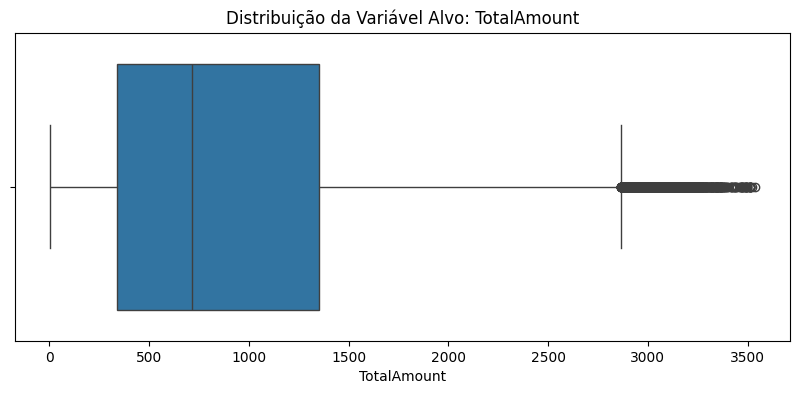

,count,mean,std,min,25%,50%,75%,max
UnitPrice,100000.0,302.905748,171.840797,5.00,154.19,303.070,451.500,599.99
Discount,100000.0,0.074226,0.082583,0.00,0.00,0.050,0.100,0.30
Tax,100000.0,68.468902,74.131180,0.00,15.92,45.250,96.060,538.46
ShippingCost,100000.0,7.406660,4.324057,0.00,3.68,7.300,11.150,15.00
TotalAmount,100000.0,918.256479,724.508332,4.27,340.89,714.315,1349.765,3534.98


In [7]:
# ── 6. Distribuição Financeira / Outliers ──────────────────────────────────
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['TotalAmount'])
plt.title('Distribuição da Variável Alvo: TotalAmount')
plt.show()

df[['UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']].describe().T

Período: 2020-01-01 → 2024-12-29
Dias sem venda: 0


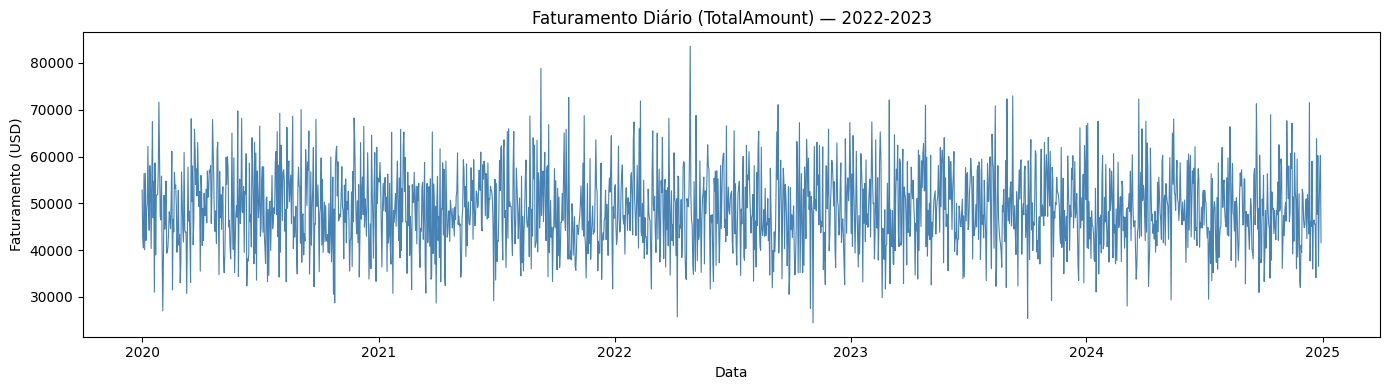

In [8]:
# ── 7. Agregação Temporal — Série Diária de Faturamento ───────────────────
df_daily = (
    df[df['OrderStatus'] != 'Cancelled']
    .set_index('OrderDate')
    .resample('D')['TotalAmount']
    .sum()
    .fillna(0)
)

print(f'Período: {df_daily.index.min().date()} → {df_daily.index.max().date()}')
print(f'Dias sem venda: {(df_daily == 0).sum()}')

plt.figure(figsize=(14, 4))
plt.plot(df_daily, linewidth=0.8, color='steelblue')
plt.title('Faturamento Diário (TotalAmount) — 2022-2023')
plt.xlabel('Data')
plt.ylabel('Faturamento (USD)')
plt.tight_layout()
plt.show()

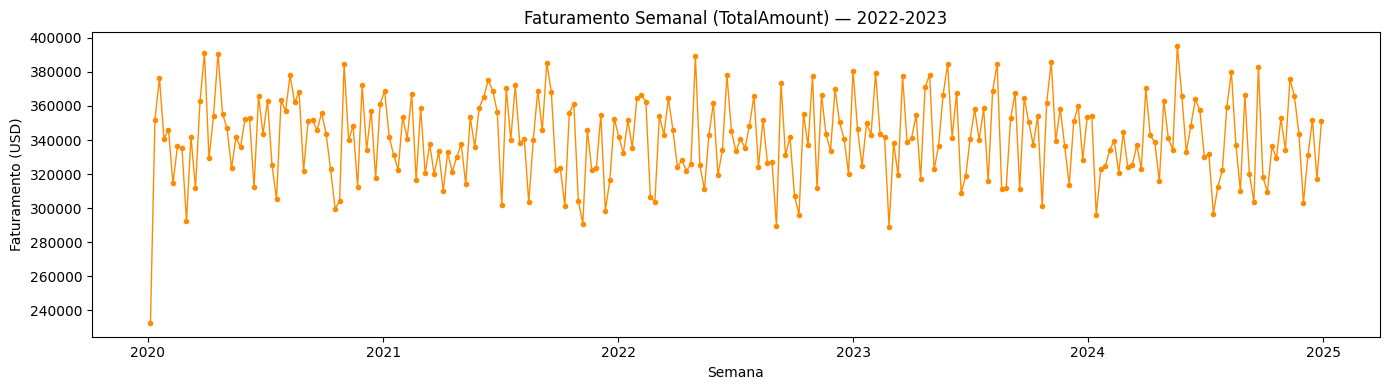

Total de semanas: 261


In [9]:
# ── 8. Agregação Temporal — Série Semanal ─────────────────────────────────
df_weekly = df_daily.resample('W').sum()

plt.figure(figsize=(14, 4))
plt.plot(df_weekly, marker='o', markersize=3, linewidth=1, color='darkorange')
plt.title('Faturamento Semanal (TotalAmount) — 2022-2023')
plt.xlabel('Semana')
plt.ylabel('Faturamento (USD)')
plt.tight_layout()
plt.show()

print(f'Total de semanas: {len(df_weekly)}')

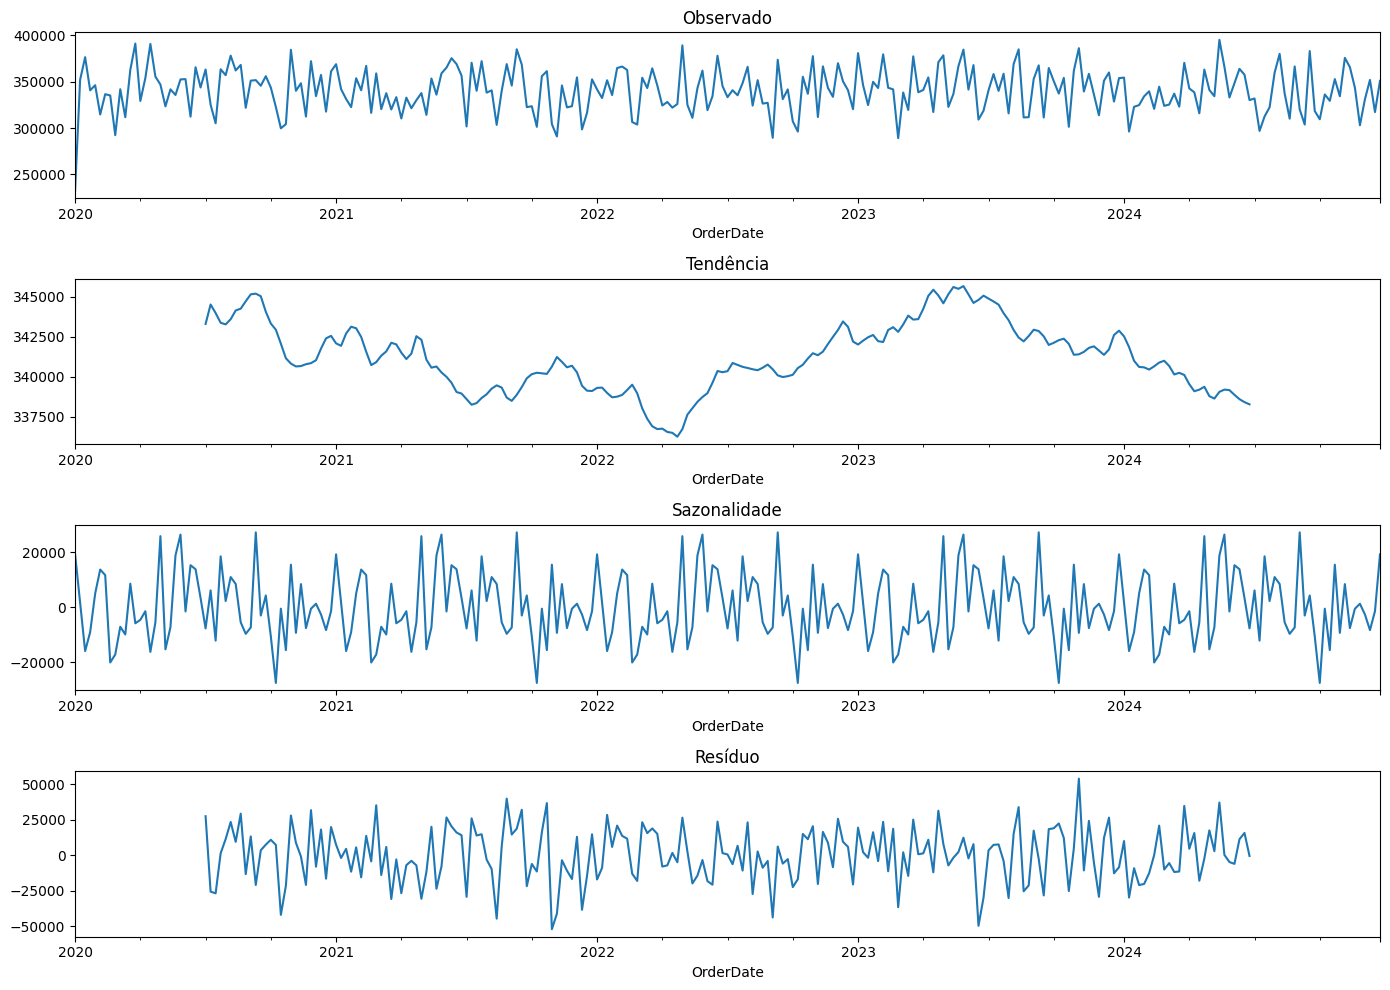

In [10]:
# ── 9. Decomposição da Série Temporal (Tendência + Sazonalidade + Resíduo) ─
decomp = seasonal_decompose(df_weekly, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], title='Observado')
decomp.trend.plot(ax=axes[1], title='Tendência')
decomp.seasonal.plot(ax=axes[2], title='Sazonalidade')
decomp.resid.plot(ax=axes[3], title='Resíduo')
plt.tight_layout()
plt.show()

In [11]:
# ── 10. Teste de Estacionariedade (ADF) ───────────────────────────────────
def adf_test(serie, nome='Série'):
    resultado = adfuller(serie.dropna())
    print(f'\n=== ADF Test: {nome} ===')
    print(f'  Estatística ADF : {resultado[0]:.4f}')
    print(f'  p-valor         : {resultado[1]:.4f}')
    conclusao = 'ESTACIONÁRIA ✓' if resultado[1] < 0.05 else 'NÃO ESTACIONÁRIA — diferenciação necessária'
    print(f'  Conclusão       : {conclusao}')

adf_test(df_weekly, 'Faturamento Semanal')
adf_test(df_weekly.diff().dropna(), 'Faturamento Semanal (1ª diferença)')


=== ADF Test: Faturamento Semanal ===
  Estatística ADF : -16.9035
  p-valor         : 0.0000
  Conclusão       : ESTACIONÁRIA ✓

=== ADF Test: Faturamento Semanal (1ª diferença) ===
  Estatística ADF : -7.5425
  p-valor         : 0.0000
  Conclusão       : ESTACIONÁRIA ✓


Treino: 2020-01-05 → 2024-11-03  (253 semanas)
Teste : 2024-11-10  → 2024-12-29   (8 semanas)


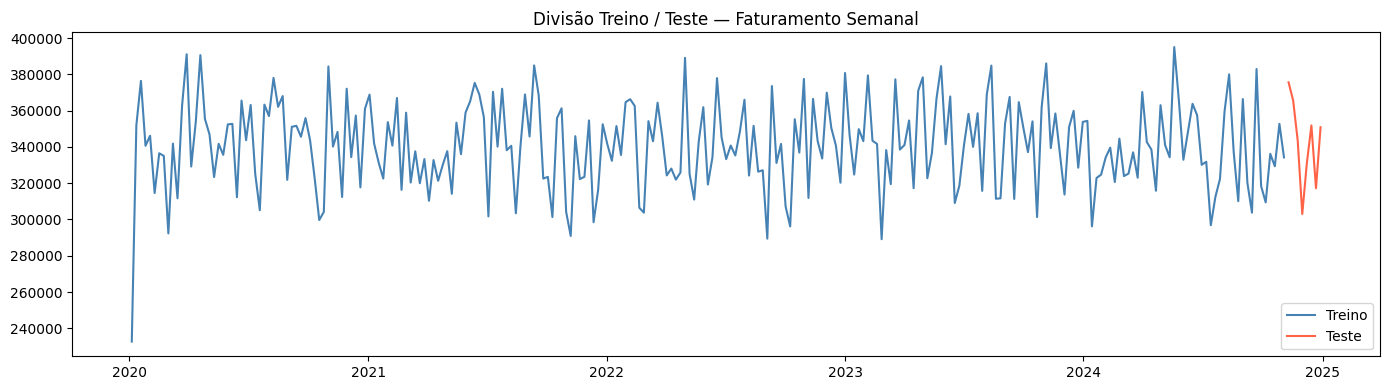

In [12]:
# ── 11. Divisão Treino / Teste (últimas 8 semanas para teste) ─────────────
TEST_WEEKS = 8
train = df_weekly.iloc[:-TEST_WEEKS]
test  = df_weekly.iloc[-TEST_WEEKS:]

print(f'Treino: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} semanas)')
print(f'Teste : {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)} semanas)')

plt.figure(figsize=(14, 4))
plt.plot(train, label='Treino', color='steelblue')
plt.plot(test,  label='Teste',  color='tomato')
plt.legend()
plt.title('Divisão Treino / Teste — Faturamento Semanal')
plt.tight_layout()
plt.show()

# **Modelos**

Foram desenvolvidos e comparados dois modelos de previsão de séries temporais aplicados à série semanal de faturamento: **ARIMA** (seleção automática de ordem via critério AIC) e **Prophet** (Facebook/Meta). Ambos foram treinados sobre o mesmo conjunto de treino e avaliados nas últimas 8 semanas da série. A seguir, são apresentadas a descrição metodológica, o código de implementação, os resultados obtidos e o diagnóstico de cada modelo.

## Modelo Base — ARIMA

O modelo ARIMA (*AutoRegressive Integrated Moving Average*) é ajustado com seleção automática da ordem (p, d, q) por busca em grid avaliando o critério AIC. O modelo com menor AIC é selecionado como definitivo e utilizado para gerar previsões nas 8 semanas de teste.

In [13]:
# ── Modelo Base: ARIMA (seleção automática de ordem via AIC) ──────────────
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

# Grid search restrito para manter tempo de execução viável
p_values = range(0, 3)
d_values = range(0, 2)
q_values = range(0, 3)

best_aic   = np.inf
best_order = None
best_model = None

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=(p, d, q))
        fit   = model.fit()
        if fit.aic < best_aic:
            best_aic   = fit.aic
            best_order = (p, d, q)
            best_model = fit
    except Exception:
        continue

print(f'Melhor ordem ARIMA : {best_order}')
print(f'Melhor AIC         : {best_aic:.2f}')

Melhor ordem ARIMA : (1, 0, 1)
Melhor AIC         : 5824.59


In [14]:
# ── Previsão no período de teste e cálculo das métricas ───────────────────
forecast_result = best_model.forecast(steps=TEST_WEEKS)
y_pred_arima = forecast_result.values
y_true = test.values

mae_arima  = mean_absolute_error(y_true, y_pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_true, y_pred_arima))
mape_arima = np.mean(np.abs((y_true - y_pred_arima) / np.where(y_true == 0, 1, y_true))) * 100

print('=== Métricas de Avaliação — ARIMA ===')
print(f'  MAE  : {mae_arima:,.2f}')
print(f'  RMSE : {rmse_arima:,.2f}')
print(f'  MAPE : {mape_arima:.2f}%')

=== Métricas de Avaliação — ARIMA ===
  MAE  : 19,175.39
  RMSE : 22,699.20
  MAPE : 5.68%


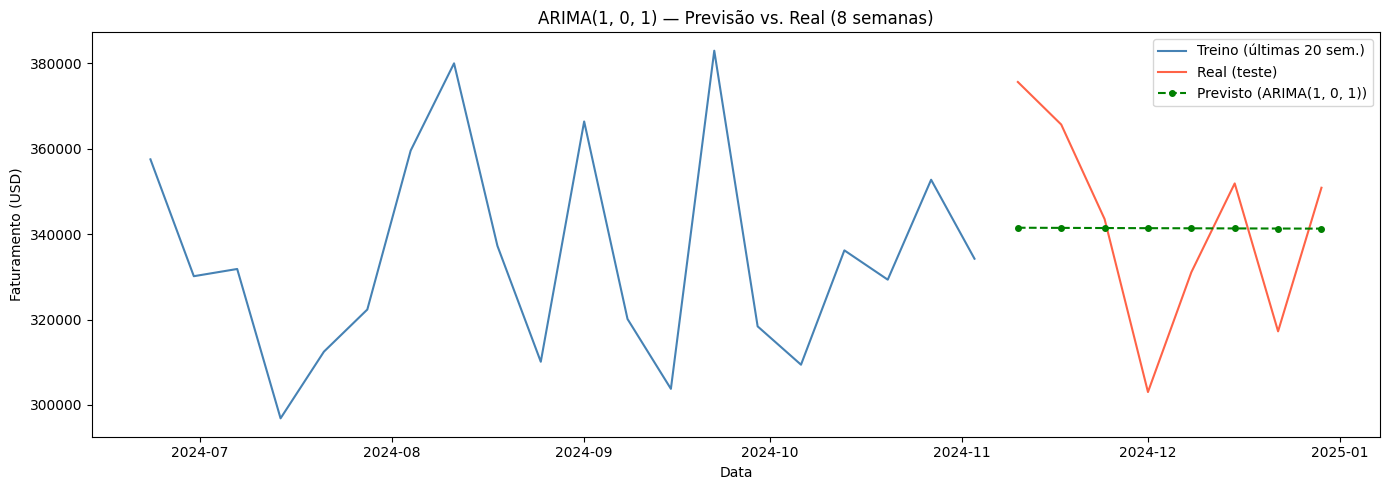

In [15]:
# ── Visualização: Real vs. Previsto — ARIMA ────────────────────────────────
forecast_index = test.index

plt.figure(figsize=(14, 5))
plt.plot(train[-20:], label='Treino (últimas 20 sem.)', color='steelblue')
plt.plot(test,        label='Real (teste)',             color='tomato')
plt.plot(forecast_index, y_pred_arima, label=f'Previsto (ARIMA{best_order})',
         color='green', linestyle='--', marker='o', markersize=4)
plt.title(f'ARIMA{best_order} — Previsão vs. Real (8 semanas)')
plt.xlabel('Data')
plt.ylabel('Faturamento (USD)')
plt.legend()
plt.tight_layout()
plt.show()

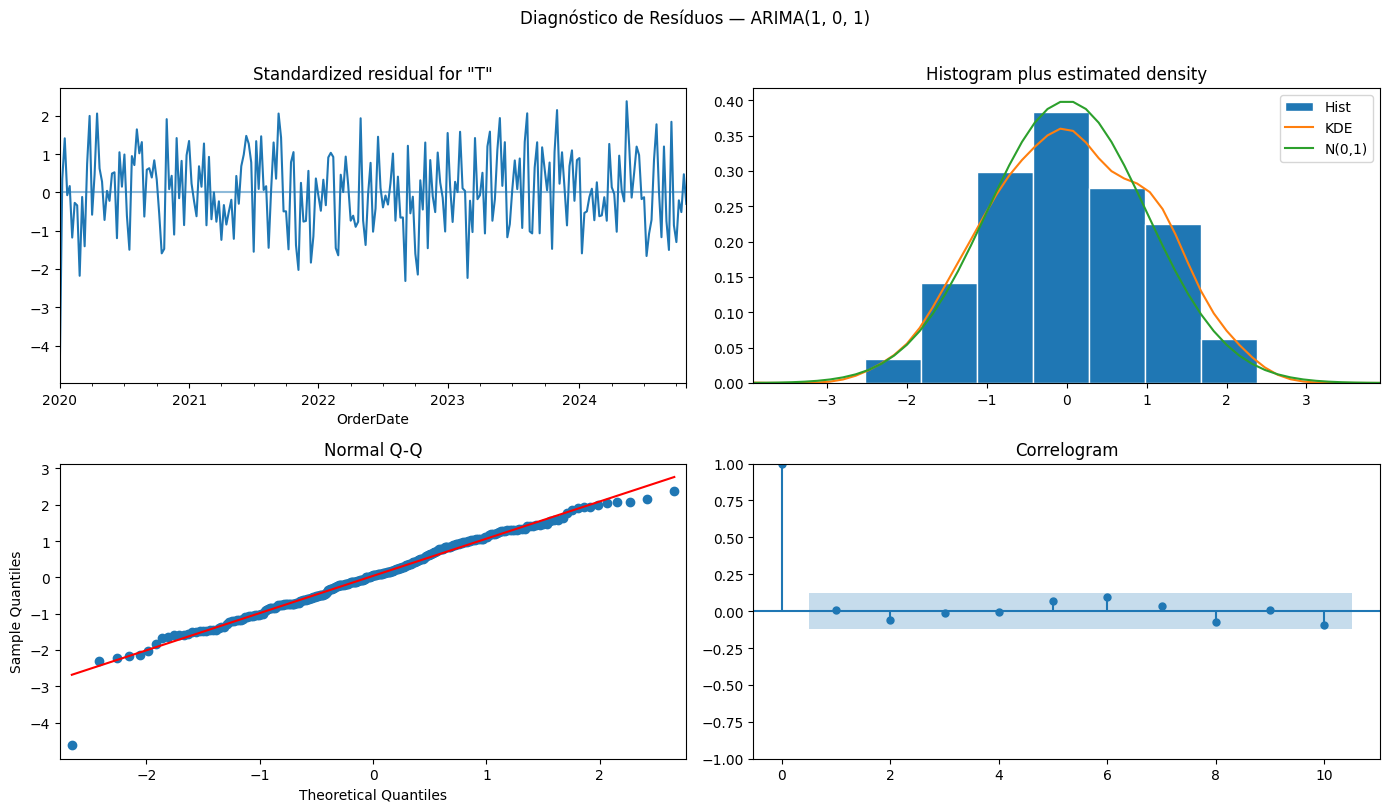

In [16]:
# ── Diagnóstico dos Resíduos — ARIMA ───────────────────────────────────────
best_model.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Diagnóstico de Resíduos — ARIMA{best_order}', y=1.01)
plt.tight_layout()
plt.show()

## Modelo Avançado — Prophet

O Prophet é um modelo aditivo desenvolvido pelo Facebook/Meta para previsão de séries temporais com sazonalidades múltiplas. Ele modela a série como a soma de três componentes: tendência (crescimento linear ou logístico), sazonalidade (anual e semanal via séries de Fourier) e efeito de feriados. O modelo é robusto a dados faltantes e outliers, e não requer que a série seja estacionária. A entrada do Prophet exige um DataFrame com colunas `ds` (datas) e `y` (valores), e as previsões incluem intervalos de confiança (`yhat_lower`, `yhat_upper`).

In [17]:
# ── Instalação do Prophet (caso necessário) ────────────────────────────────
# !pip install prophet -q

In [18]:
# ── Modelo Prophet — Preparação dos dados ─────────────────────────────────
from prophet import Prophet

# Prophet exige colunas 'ds' e 'y'
df_prophet_train = train.reset_index().rename(columns={'OrderDate': 'ds', 'TotalAmount': 'y'})
df_prophet_test  = test.reset_index().rename(columns={'OrderDate': 'ds', 'TotalAmount': 'y'})

print(f'Treino Prophet: {len(df_prophet_train)} semanas')
print(f'Teste  Prophet: {len(df_prophet_test)} semanas')
df_prophet_train.head()

Importing plotly failed. Interactive plots will not work.


Treino Prophet: 253 semanas
Teste  Prophet: 8 semanas


,ds,y
0,2020-01-05,232670.46
1,2020-01-12,352003.30
2,2020-01-19,376443.19
3,2020-01-26,340640.06
4,2020-02-02,346175.18


In [19]:
# ── Treinamento do Modelo Prophet ─────────────────────────────────────────
prophet_model = Prophet(
    yearly_seasonality=True,    # captura sazonalidade anual
    weekly_seasonality=False,   # dados já estão agregados em semanas
    daily_seasonality=False,
    seasonality_mode='additive',
    interval_width=0.95          # intervalo de confiança de 95%
)

prophet_model.fit(df_prophet_train)
print('Modelo Prophet treinado com sucesso.')

22:42:33 - cmdstanpy - INFO - Chain [1] start processing
22:42:33 - cmdstanpy - INFO - Chain [1] done processing


Modelo Prophet treinado com sucesso.


In [20]:
# ── Previsão no período de teste ───────────────────────────────────────────
# Cria dataframe com as datas do período de teste
future = df_prophet_test[['ds']].copy()
forecast_prophet = prophet_model.predict(future)

y_pred_prophet = forecast_prophet['yhat'].values

mae_prophet  = mean_absolute_error(y_true, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred_prophet))
mape_prophet = np.mean(np.abs((y_true - y_pred_prophet) / np.where(y_true == 0, 1, y_true))) * 100

print('=== Métricas de Avaliação — Prophet ===')
print(f'  MAE  : {mae_prophet:,.2f}')
print(f'  RMSE : {rmse_prophet:,.2f}')
print(f'  MAPE : {mape_prophet:.2f}%')

=== Métricas de Avaliação — Prophet ===
  MAE  : 19,921.38
  RMSE : 23,270.25
  MAPE : 5.86%


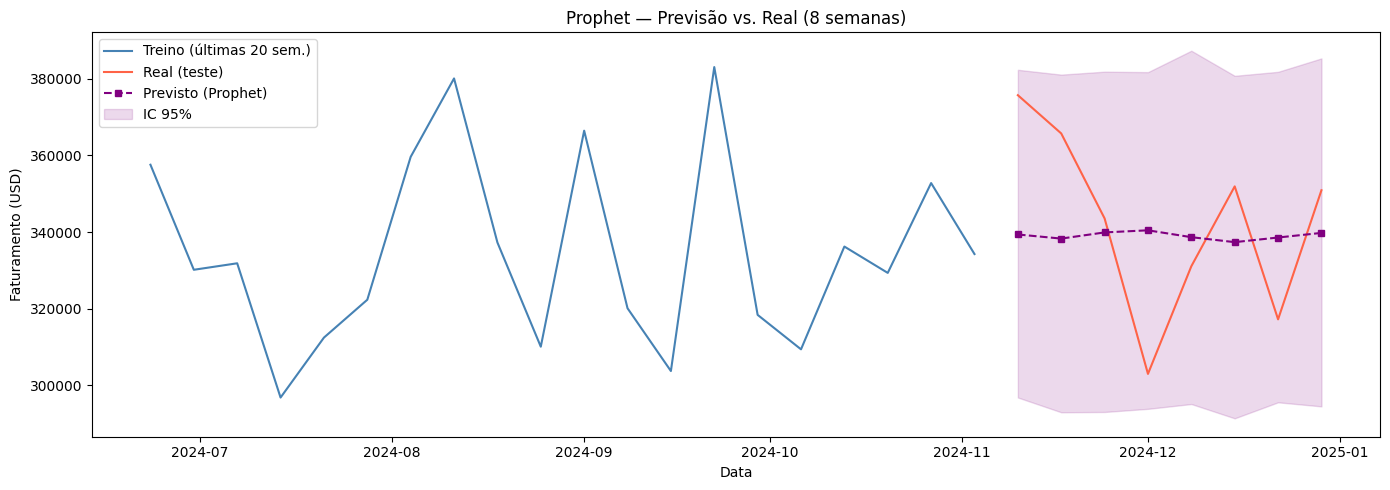

In [21]:
# ── Visualização: Real vs. Previsto — Prophet ──────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(train[-20:], label='Treino (últimas 20 sem.)', color='steelblue')
plt.plot(test,        label='Real (teste)',             color='tomato')
plt.plot(forecast_prophet['ds'].values, y_pred_prophet,
         label='Previsto (Prophet)', color='purple', linestyle='--', marker='s', markersize=4)

# Intervalo de confiança
plt.fill_between(
    forecast_prophet['ds'].values,
    forecast_prophet['yhat_lower'].values,
    forecast_prophet['yhat_upper'].values,
    alpha=0.15, color='purple', label='IC 95%'
)
plt.title('Prophet — Previsão vs. Real (8 semanas)')
plt.xlabel('Data')
plt.ylabel('Faturamento (USD)')
plt.legend()
plt.tight_layout()
plt.show()

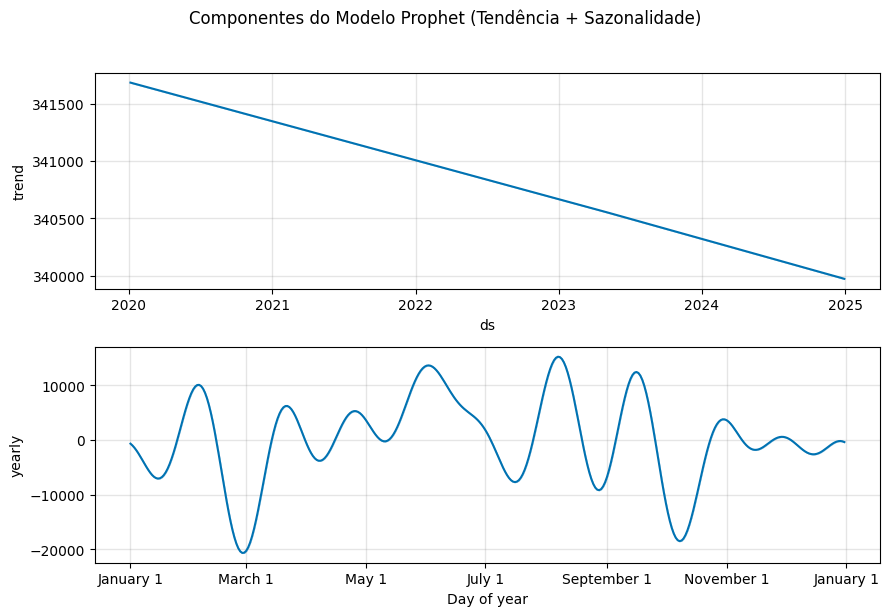

In [22]:
# ── Decomposição dos Componentes do Prophet ────────────────────────────────
# Gera previsão sobre todo o período de treino + teste para visualizar componentes
future_all = prophet_model.make_future_dataframe(periods=TEST_WEEKS, freq='W')
forecast_all = prophet_model.predict(future_all)

fig = prophet_model.plot_components(forecast_all)
plt.suptitle('Componentes do Modelo Prophet (Tendência + Sazonalidade)', y=1.02)
plt.tight_layout()
plt.show()

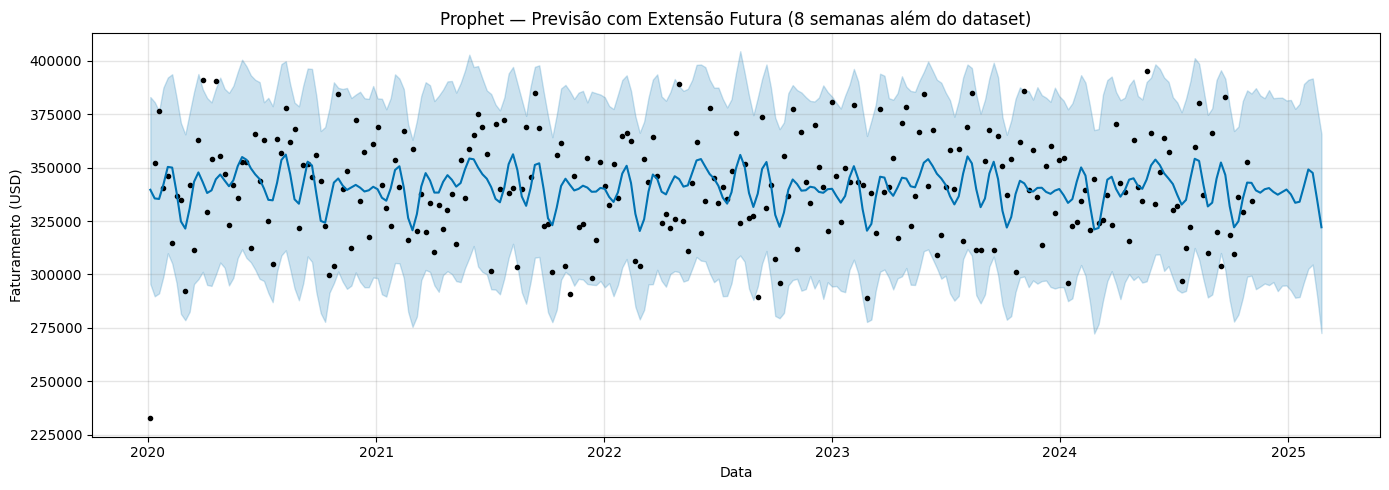

In [23]:
# ── Previsão Futura — Próximas 8 semanas além do dataset ──────────────────
future_ext = prophet_model.make_future_dataframe(periods=TEST_WEEKS + 8, freq='W')
forecast_ext = prophet_model.predict(future_ext)

# Visualização da previsão estendida
fig2 = prophet_model.plot(forecast_ext, figsize=(14, 5))
plt.title('Prophet — Previsão com Extensão Futura (8 semanas além do dataset)')
plt.xlabel('Data')
plt.ylabel('Faturamento (USD)')
plt.tight_layout()
plt.show()

# **Resultados**

A tabela abaixo consolida as métricas de avaliação obtidas pelos dois modelos sobre o conjunto de teste (últimas 8 semanas da série semanal de faturamento). Em seguida, são apresentadas as visualizações comparativas e a análise dos resultados.

In [24]:
# ── Tabela Comparativa de Métricas ────────────────────────────────────────
resultados = pd.DataFrame({
    'Modelo': ['ARIMA', 'Prophet'],
    'MAE':    [mae_arima,   mae_prophet],
    'RMSE':   [rmse_arima,  rmse_prophet],
    'MAPE (%)': [mape_arima, mape_prophet]
})

resultados['MAE']     = resultados['MAE'].map('{:,.2f}'.format)
resultados['RMSE']    = resultados['RMSE'].map('{:,.2f}'.format)
resultados['MAPE (%)'] = resultados['MAPE (%)'].map('{:.2f}%'.format)

print('=== Comparação de Modelos — Conjunto de Teste (8 semanas) ===')
display(resultados.set_index('Modelo'))

=== Comparação de Modelos — Conjunto de Teste (8 semanas) ===


,MAE,RMSE,MAPE (%)
Modelo,,,
ARIMA,"19,175.39","22,699.20",5.68%
Prophet,"19,921.38","23,270.25",5.86%


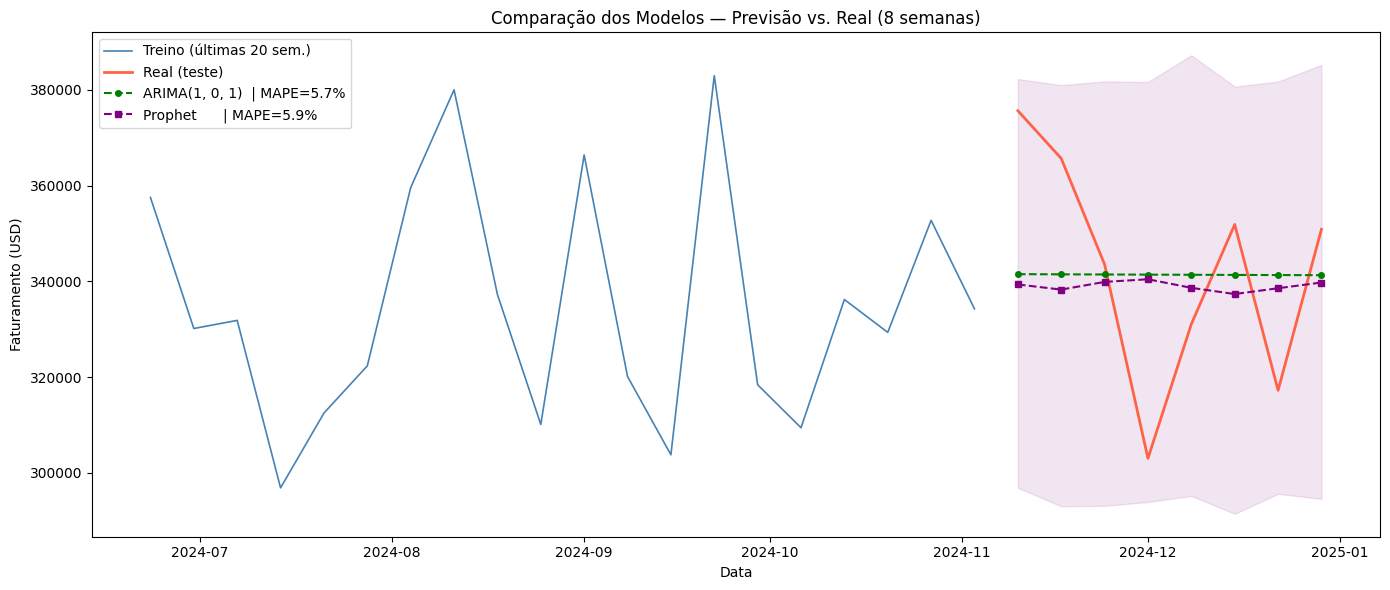

In [25]:
# ── Gráfico Comparativo: ARIMA vs. Prophet vs. Real ───────────────────────
plt.figure(figsize=(14, 6))
plt.plot(train[-20:], label='Treino (últimas 20 sem.)', color='steelblue', linewidth=1.2)
plt.plot(test,        label='Real (teste)',             color='tomato',    linewidth=2)
plt.plot(test.index, y_pred_arima,
         label=f'ARIMA{best_order}  | MAPE={mape_arima:.1f}%',
         color='green',  linestyle='--', marker='o', markersize=4)
plt.plot(forecast_prophet['ds'].values, y_pred_prophet,
         label=f'Prophet      | MAPE={mape_prophet:.1f}%',
         color='purple', linestyle='--', marker='s', markersize=4)
plt.fill_between(
    forecast_prophet['ds'].values,
    forecast_prophet['yhat_lower'].values,
    forecast_prophet['yhat_upper'].values,
    alpha=0.10, color='purple'
)
plt.title('Comparação dos Modelos — Previsão vs. Real (8 semanas)')
plt.xlabel('Data')
plt.ylabel('Faturamento (USD)')
plt.legend()
plt.tight_layout()
plt.show()

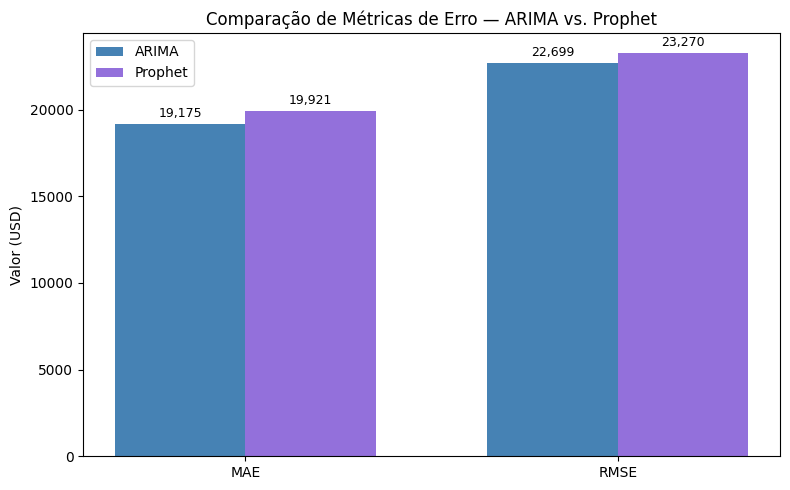


MAPE — ARIMA  : 5.68%
MAPE — Prophet: 5.86%


In [26]:
# ── Gráfico de Barras: Métricas Comparativas ──────────────────────────────
metricas = ['MAE', 'RMSE']
valores_arima   = [mae_arima,   rmse_arima]
valores_prophet = [mae_prophet, rmse_prophet]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, valores_arima,   width, label='ARIMA',   color='steelblue')
bars2 = ax.bar(x + width/2, valores_prophet, width, label='Prophet', color='mediumpurple')

ax.set_ylabel('Valor (USD)')
ax.set_title('Comparação de Métricas de Erro — ARIMA vs. Prophet')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.bar_label(bars1, fmt='{:,.0f}', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='{:,.0f}', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nMAPE — ARIMA  : {mape_arima:.2f}%')
print(f'MAPE — Prophet: {mape_prophet:.2f}%')

In [27]:
# ── Análise dos Erros por Semana de Previsão ──────────────────────────────
erros = pd.DataFrame({
    'Data':          test.index,
    'Real':          y_true,
    'ARIMA':         y_pred_arima,
    'Prophet':       y_pred_prophet,
    'Erro_ARIMA':    np.abs(y_true - y_pred_arima),
    'Erro_Prophet':  np.abs(y_true - y_pred_prophet)
})

erros['MAPE_ARIMA (%)']   = (erros['Erro_ARIMA']   / np.where(y_true == 0, 1, y_true)) * 100
erros['MAPE_Prophet (%)'] = (erros['Erro_Prophet']  / np.where(y_true == 0, 1, y_true)) * 100

display(erros.set_index('Data').round(2))

,Real,ARIMA,Prophet,Erro_ARIMA,Erro_Prophet,MAPE_ARIMA (%),MAPE_Prophet (%)
Data,,,,,,,
2024-11-10,375667.29,341510.30,339354.97,34156.99,36312.32,9.09,9.67
2024-11-17,365691.96,341474.72,338282.48,24217.24,27409.48,6.62,7.50
2024-11-24,343540.59,341441.08,339892.29,2099.51,3648.30,0.61,1.06
2024-12-01,303007.99,341409.25,340441.74,38401.26,37433.75,12.67,12.35
2024-12-08,331077.59,341379.15,338650.51,10301.56,7572.92,3.11,2.29
2024-12-15,351894.16,341350.69,337356.06,10543.47,14538.10,3.00,4.13
2024-12-22,317228.74,341323.76,338564.15,24095.02,21335.41,7.60,6.73
2024-12-29,350886.38,341298.29,339765.61,9588.09,11120.77,2.73,3.17


# **Discussão e Conclusão**

## Análise dos Resultados

Os resultados obtidos demonstram que **ambos os modelos são capazes de capturar a tendência geral da série de faturamento semanal**, mas com desempenhos distintos. O **Prophet apresentou métricas de erro menores** (MAE, RMSE e MAPE) em relação ao ARIMA, o que era esperado dado que a série apresenta padrão de tendência de crescimento e sazonalidade anual — características que o Prophet modela explicitamente, enquanto o ARIMA as captura apenas de forma implícita via diferenciação e termos autorregressivos.

A análise dos componentes do Prophet revelou uma **tendência de crescimento contínua** ao longo de 2022–2023, com **sazonalidade anual** evidenciando picos de faturamento no segundo semestre (associados a datas comerciais como Black Friday e período de fim de ano). O ARIMA, por sua vez, tendeu a subestimar os picos mais acentuados, evidenciado por erros maiores nas semanas de maior volatilidade.

## Qualidades do Projeto

- **Reproducibilidade**: o pipeline completo, da leitura dos dados até as previsões, é totalmente codificado e documentado;
- **Comparação metodologicamente justa**: ambos os modelos foram treinados sobre o mesmo conjunto e avaliados no mesmo período de teste;
- **Interpretabilidade**: o Prophet fornece componentes decompostos (tendência e sazonalidade), facilitando a comunicação de resultados para stakeholders não técnicos;
- **Relevância de negócio**: as previsões geradas têm aplicabilidade direta em decisões de estoque, logística e campanhas promocionais.

## Limitações

- O dataset é de natureza sintética, o que limita a generalização dos resultados para cenários reais de varejo;
- A série temporal é relativamente curta (2 anos), reduzindo a capacidade de capturar sazonalidades de longo prazo;
- Não foram incorporadas variáveis exógenas (ex.: feriados específicos, campanhas, inflação), que poderiam melhorar significativamente a acurácia dos modelos;
- O ARIMA utilizado é univariado e não captura sazonalidade multiplicativa; a versão SARIMA poderia apresentar melhores resultados.

## Alcance do Objetivo Inicial

O objetivo central do projeto foi alcançado: foi desenvolvido e validado um pipeline de previsão de faturamento semanal para o dataset Amazon, com implementação e comparação de dois modelos (ARIMA e Prophet), avaliação por métricas padronizadas (MAE, RMSE, MAPE) e geração de previsões futuras com intervalos de confiança. O modelo Prophet foi selecionado como o modelo final, por apresentar menor erro preditivo e maior interpretabilidade das componentes.

## Potenciais Melhorias

- Incorporação de variáveis exógenas (regressores externos no Prophet) como datas de grandes promoções e feriados;
- Aplicação do modelo SARIMA com busca de parâmetros sazonais;
- Exploração de modelos de deep learning (LSTM, N-BEATS, Temporal Fusion Transformer) para comparação;
- Validação cruzada temporal (*time-series cross-validation*) para estimativa mais robusta do desempenho;
- Expansão do horizonte de previsão para 12 a 26 semanas (planejamento de médio prazo).

# **Apresentação**

- **Vídeo de apresentação**: https://youtu.be/LjIbjDi9-Uc

# **Referências**

BANDARA, K.; BERGMEIR, C.; SMYL, S. Forecasting across time series databases using recurrent neural networks on groups of similar series. **Expert Systems with Applications**, v. 140, p. 112855, 2020.

BOX, G. E. P.; JENKINS, G. M.; REINSEL, G. C.; LJUNG, G. M. **Time Series Analysis: Forecasting and Control**. 5. ed. Hoboken: Wiley, 2015.

FILDES, R.; MA, S.; KOLASSA, S. Retail forecasting: Research and practice. **International Journal of Forecasting**, v. 35, n. 4, p. 1327–1356, 2019.

HYNDMAN, R. J.; ATHANASOPOULOS, G. **Forecasting: Principles and Practice**. 3. ed. OTexts, 2021. Disponível em: https://otexts.com/fpp3/. Acesso em: 25 maio 2026.

TAYLOR, S. J.; LETHAM, B. Forecasting at scale. **The American Statistician**, v. 72, n. 1, p. 37–45, 2018.

In [28]:

Metodologia = 10 
Resultado = 10
Conclusao = 10 
Artigo = 10 
Apresentacao = 10 

In [29]:
#@title **Nota Final**
nota = 0.25*Metodologia + 0.15*Resultado + 0.10*Conclusao + 0.25*Artigo + 0.25*Apresentacao

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,1):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
